<a href="https://colab.research.google.com/github/RecSys-lab/RAG-VisualRec/blob/main/codes/dot_chart_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dot Chart of Retrieval and Recommender Data - Rec-Temp**

**I. Data**

In [ ]:
import pandas as pd

# Get data (Recall Temp from Accuracy-Run2)
df_retrieval = pd.DataFrame([
    ["Visual + Textual (ST) CCA", 20, 10, 0.167939],
    ["Visual + Textual (ST) CCA", 30, 10, 0.184319],
    ["Visual + Textual (ST) CCA", 50, 10, 0.205637],
    ["Visual + Textual (ST) CCA", 100, 10, 0.205637],
    ["Visual + Textual (ST) CCA", 150, 10, 0.205637],
    ["ST Unimodal", 20, 10, 0.10091],
    ["ST Unimodal", 30, 10, 0.118879],
    ["ST Unimodal", 50, 10, 0.160541],
    ["ST Unimodal", 100, 10, 0.160541],
    ["ST Unimodal", 150, 10, 0.160541],
    ["Visual Unimodal", 20, 10, 0.02203],
    ["Visual Unimodal", 30, 10, 0.027576],
    ["Visual Unimodal", 50, 10, 0.036688],
    ["Visual Unimodal", 100, 10, 0.036688],
    ["Visual Unimodal", 150, 10, 0.036688],
], columns=["Method", "N", "k", "Recall"])


df_recom_manual = pd.DataFrame([
    ["Visual + Textual (ST) CCA", 20, 10, 0.120675],
    ["Visual + Textual (ST) CCA", 30, 10, 0.117986],
    ["Visual + Textual (ST) CCA", 50, 10, 0.107084],
    ["Visual + Textual (ST) CCA", 100, 10, 0.094747],
    ["Visual + Textual (ST) CCA", 150, 10, 0.090061],
    ["ST Unimodal", 20, 10, 0.069387],
    ["ST Unimodal", 30, 10, 0.07043],
    ["ST Unimodal", 50, 10, 0.084321],
    ["ST Unimodal", 100, 10, 0.07128],
    ["ST Unimodal", 150, 10, 0.073144],
    ["Visual Unimodal", 20, 10, 0.016384],
    ["Visual Unimodal", 30, 10, 0.016402],
    ["Visual Unimodal", 50, 10, 0.01611],
    ["Visual Unimodal", 100, 10, 0.017697],
    ["Visual Unimodal", 150, 10, 0.017655],
], columns=["Method", "N", "k", "Recall"])

df_recom_llm = pd.DataFrame([
    ["Visual + Textual (ST) CCA", 20, 10, 0.11467],
    ["Visual + Textual (ST) CCA", 30, 10, 0.105045],
    ["Visual + Textual (ST) CCA", 50, 10, 0.097654],
    ["Visual + Textual (ST) CCA", 100, 10, 0.083148],
    ["Visual + Textual (ST) CCA", 150, 10, 0.080985],
    ["ST Unimodal", 20, 10, 0.07131],
    ["ST Unimodal", 30, 10, 0.071879],
    ["ST Unimodal", 50, 10, 0.0773],
    ["ST Unimodal", 100, 10, 0.070669],
    ["ST Unimodal", 150, 10, 0.067711],
    ["Visual Unimodal", 20, 10, 0.015929],
    ["Visual Unimodal", 30, 10, 0.018761],
    ["Visual Unimodal", 50, 10, 0.01734],
    ["Visual Unimodal", 100, 10, 0.022153],
    ["Visual Unimodal", 150, 10, 0.017315],
], columns=["Method", "N", "k", "Recall"])

df_retrieval.head(5)

,Method,N,k,Recall
0,Visual + Textual (ST) CCA,20,10,0.167939
1,Visual + Textual (ST) CCA,30,10,0.184319
2,Visual + Textual (ST) CCA,50,10,0.205637
3,Visual + Textual (ST) CCA,100,10,0.205637
4,Visual + Textual (ST) CCA,150,10,0.205637


**II. Radar Chart (Recall@10)**

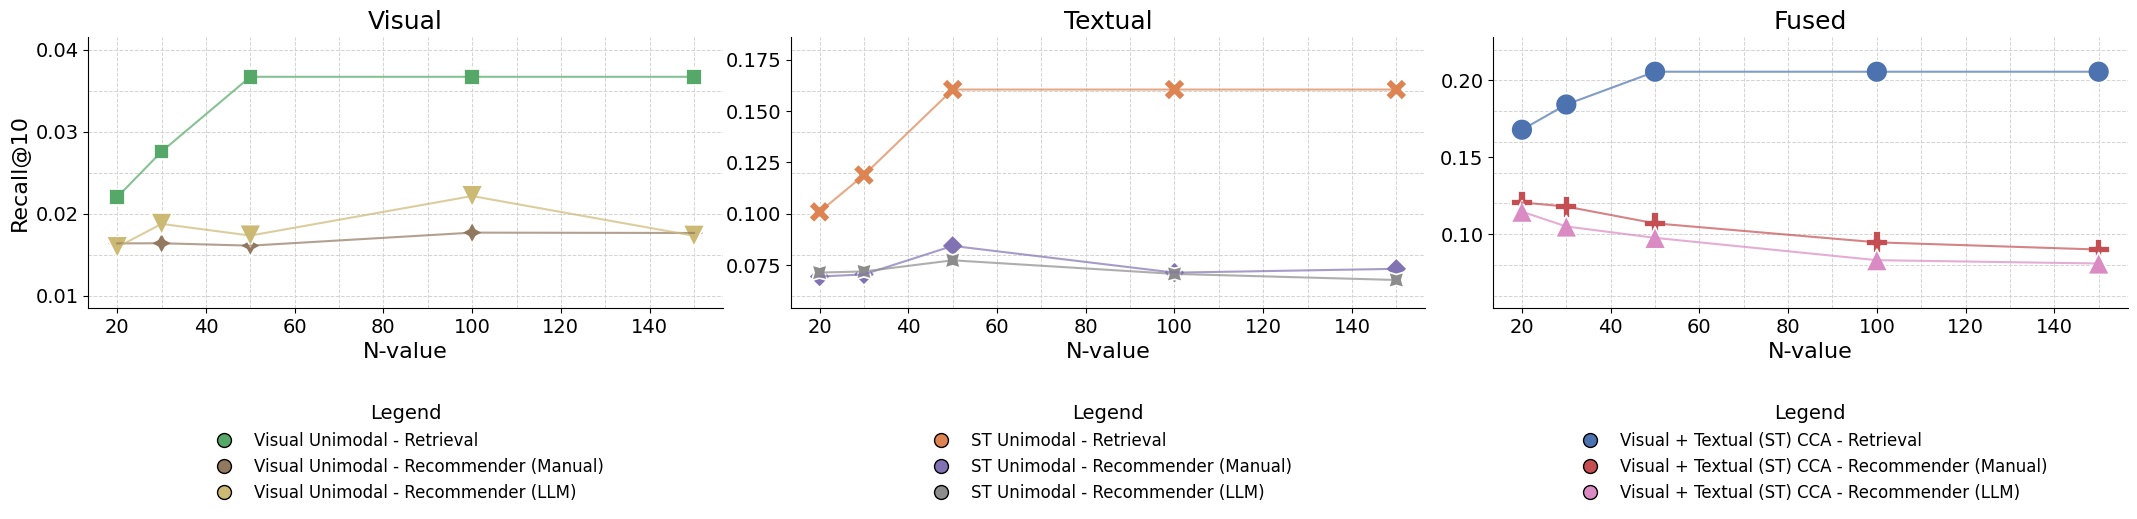

In [ ]:
# @title Default title text
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Augment with a 'Source' column
df_retrieval['Source'] = 'Retrieval'
df_recom_llm['Source'] = 'Recommender (LLM)'
df_recom_manual['Source'] = 'Recommender (Manual)'

# Combine them all together
combined_df = pd.concat([df_retrieval, df_recom_manual, df_recom_llm], ignore_index=True)

# Map methods to categories for subplots
method_to_category = {
    "Visual Unimodal": "Visual",
    "ST Unimodal": "Textual",
    "Visual + Textual (ST) CCA": "Fused"
}

# Add a 'Category' column
combined_df['Category'] = combined_df['Method'].map(method_to_category)

# Filter out rows where Category is NaN (if any methods are not mapped)
combined_df = combined_df.dropna(subset=['Category'])

# Create a new column for the legend that combines Method and Source
combined_df['LegendLabel'] = combined_df['Method'] + ' - ' + combined_df['Source']

# Create the dot chart with subplots
g = sns.relplot(
    data=combined_df,
    x="N",
    y="Recall",
    hue="LegendLabel",
    style="LegendLabel",
    col="Category",
    kind="scatter",
    col_order=["Visual", "Textual", "Fused"],
    height=6,
    aspect=1.2,
    s=250, # size of dots
    palette="deep",
    facet_kws={'sharey': False},
    legend=False # Disable the figure-level legend
)

# Get unique legend labels (global order)
legend_labels = combined_df["LegendLabel"].unique()

# Recreate the color palette used by seaborn
palette = sns.color_palette("deep", len(legend_labels))
color_map = dict(zip(legend_labels, palette))

# Increase font size for axis labels and subplot titles
g.set_axis_labels("N-value", "Recall@10", fontsize=16)

g.set_titles("{col_name}")

for ax in g.axes.flat:
    # Increase title font-size
    ax.set_title(ax.get_title(), fontsize=18)
    # Axis font-size
    ax.tick_params(axis='both', which='major', labelsize=14)

for ax, category in zip(g.axes.flat, ["Visual", "Textual", "Fused"]):

    subset = combined_df[combined_df["Category"] == category]
    labels_in_ax = subset["LegendLabel"].unique()

    handles = []

    for label in labels_in_ax:
        proxy = plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='None',
            markerfacecolor=color_map[label],
            markeredgecolor='black',
            markersize=10,
            label=label
        )
        handles.append(proxy)

    ax.legend(
        handles=handles,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.30),
        frameon=False,
        fontsize=12,
        title="Legend",
        title_fontsize=14
    )

# Grid Lines
for ax in g.axes.flat:
    # Get current axis limits
    xmin, xmax = 20, 150
    ymin, ymax = ax.get_ylim()

    # ---- Vertical lines every 10 N ----
    for x in range(int(xmin // 10 * 10), int(xmax) + 1, 10):
        ax.axvline(
            x=x,
            color='lightgray',
            linestyle='--',
            linewidth=0.7,
            zorder=0
        )

    # ---- Horizontal lines at Recall ticks ----
    for y in ax.get_yticks():
        ax.axhline(
            y=y,
            color='lightgray',
            linestyle='--',
            linewidth=0.7,
            zorder=0
        )

# Recreate the same color mapping used by seaborn
legend_labels = combined_df["LegendLabel"].unique()
palette = sns.color_palette("deep", len(legend_labels))
color_map = dict(zip(legend_labels, palette))

# Draw lines connecting points of the same LegendLabel
for ax, category in zip(g.axes.flat, ["Visual", "Textual", "Fused"]):

    subset_cat = combined_df[combined_df["Category"] == category]

    for label, color in color_map.items():
        subset_label = subset_cat[subset_cat["LegendLabel"] == label]

        if subset_label.empty:
            continue

        subset_label = subset_label.sort_values("N")

        ax.plot(
            subset_label["N"],
            subset_label["Recall"],
            color=color,
            linewidth=1.5,
            alpha=0.7,
            zorder=1   # behind scatter points
        )

plt.tight_layout()
plt.savefig("dot-chart.pdf", format='pdf', bbox_inches='tight')
plt.show()